In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/My Drive/single_cell_isoform_smoothing/

/content/drive/My Drive/single_cell_isoform_smoothing


In [3]:
!pip install --upgrade networkx
!pip install scanpy
!pip install SCORED

In [4]:
import sklearn
import scipy
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from tqdm.notebook import tqdm
import networkx as nx
from scipy.stats import spearmanr
import numpy as np
import torch
import scanpy as sc
import pandas as pd
from scipy.sparse import csr_matrix
from anndata import AnnData
from typing import Optional, List
from scored import SCORED


In [5]:
def read_data(flowcell, dataset):
    adata_raw = sc.read_h5ad(
        f"./{dataset}_new/transcript_raw_{flowcell}.h5ad"
    )
    adata_refined = sc.read_h5ad(
        f"./{dataset}_new/transcript_new_{flowcell}.h5ad"
    )
    pseudotime_metadata = pd.read_csv(
        f'./{dataset}_new/meta_data_pseudotime.csv',
        index_col=0
    )

    adata_raw = adata_raw[adata_raw.obs.index.isin(pseudotime_metadata['cell_names'])]
    sc.pp.normalize_total(adata_raw, target_sum=1e4)

    adata_raw.obs['pseudotime'] = pseudotime_metadata.set_index('cell_names')['pseudotime'].loc[adata_raw.obs.index].values

    adata_refined = adata_refined[adata_refined.obs.index.isin(pseudotime_metadata['cell_names'])]
    adata_refined.obs['pseudotime'] = pseudotime_metadata.set_index('cell_names')['pseudotime'].loc[adata_refined.obs.index].values

    return adata_raw, adata_refined, pseudotime_metadata


In [6]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

def plot_isoform_expression_and_regression(adata_raw, adata_refined, isoform_names):

    fig, axs = plt.subplots(2, len(isoform_names), figsize=(2 * len(isoform_names), 6), dpi=256, sharex=True, sharey=True)

    adata_raw.var["mt"] = adata_raw.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(
        adata_raw, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
    )
    sc.pp.normalize_total(adata_raw, target_sum=1e4)
    for i, isoform_name in enumerate(isoform_names):

        raw_expr = np.log1p(adata_raw[:, isoform_name].X.toarray().reshape(-1))
        refined_expr = adata_refined[:, isoform_name].X.toarray().reshape(-1)
        pseudotime = adata_raw.obs['pseudotime'].to_numpy()

        raw_lowess_result = sm.nonparametric.lowess(raw_expr, pseudotime, frac=0.6)
        refined_lowess_result = sm.nonparametric.lowess(refined_expr, pseudotime, frac=0.6)

        axs[0,i].scatter(pseudotime, raw_expr, color='tab:blue', alpha=0.2, label='Raw Expression')
        axs[0,i].plot(raw_lowess_result[:, 0], raw_lowess_result[:, 1], color='tab:orange', label='LOWESS')

        axs[1,i].scatter(pseudotime, refined_expr, color='tab:green', alpha=0.2, label='Refined Expression')
        axs[1,i].plot(refined_lowess_result[:, 0], refined_lowess_result[:, 1], color='tab:orange', label='LOWESS')

        axs[0,i].spines['right'].set_visible(False)
        axs[0,i].spines['top'].set_visible(False)
        axs[1,i].spines['right'].set_visible(False)
        axs[1,i].spines['top'].set_visible(False)

        axs[0,i].set_title(isoform_name)
        axs[1,i].set_xlabel('Pseudotime')

    axs[0,0].set_ylabel(f'Raw - log(Expression)')
    axs[1,0].set_ylabel(f'Refined - log(Expression)')
    axs[0,len(isoform_names)-1].legend(loc='center left', bbox_to_anchor=(1.2, 1))
    axs[1,len(isoform_names)-1].legend(loc='center left', bbox_to_anchor=(1.2, 1))

    plt.show()


In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_isoform_2x2(
    adata_dict, isoform, ylim=None, xlim=None,
    drop_top_pct=0.05, use_global_cut=True, sharey=False
):
    colors = {'with_pge2': '#E41A1C', 'no_pge2': '#377EB8'}
    conds  = ['no_pge2', 'with_pge2']
    phases = ['raw', 'refined']

    phase_labels = {'raw': 'Original', 'refined': 'Refined'}
    cond_labels  = {'with_pge2': 'IL1B+IL23+PGE2', 'no_pge2': 'IL1B+IL23'}

    all_x = []
    for cond in conds:
        adata_raw, adata_refined = adata_dict[cond]
        all_x.append(adata_raw.obs['pseudotime'])
        all_x.append(adata_refined.obs['pseudotime'])
    all_x = pd.concat(all_x)

    if xlim is None:
        xmin = float(all_x.min())
        xmax_base = float(all_x.max())
        if drop_top_pct and use_global_cut:
            xmax = float(all_x.quantile(1 - drop_top_pct))
        else:
            xmax = xmax_base
        xlim = (xmin, xmax)

    fig, axes = plt.subplots(2, 2, figsize=(8, 6), dpi=200, sharex=True, sharey=sharey)

    for i, phase in enumerate(phases):
        for j, cond in enumerate(conds):
            ax = axes[i, j]
            adata_raw, adata_refined = adata_dict[cond]
            adata = adata_raw if phase == 'raw' else adata_refined

            if isoform not in adata.var_names:
                ax.text(0.5, 0.5, f"{isoform} not found", ha='center', va='center')
                ax.set_axis_off()
                continue

            x_series = adata.obs['pseudotime']
            if drop_top_pct:
                cutoff = xlim[1] if use_global_cut else float(x_series.quantile(1 - drop_top_pct))
                mask = x_series <= cutoff
                ad = adata[mask].copy()
            else:
                ad = adata

            expr = ad.obs_vector(isoform)
            if phase == 'raw':
                expr = np.log1p(expr)
            x = ad.obs['pseudotime'].to_numpy()

            sns.scatterplot(x=x, y=expr, ax=ax, s=5, color=colors[cond],
                            alpha=0.3, linewidth=0, zorder=1)
            sns.kdeplot(x=x, y=expr, ax=ax, fill=True,
                        levels=5, thresh=0.05, cut=0,
                        color=colors[cond], alpha=0.6)

            base_rgb = mcolors.to_rgb(colors[cond])
            darker_hex = mcolors.to_hex(tuple(c*0.6 for c in base_rgb))
            sns.regplot(x=x, y=expr, ax=ax, scatter=False, lowess=True,
                        line_kws={'color': darker_hex})

            ax.set_title(f"{phase_labels[phase]} - {cond_labels[cond]}")
            ax.set_ylabel(f"{isoform} Expression")
            ax.set_xlim(xlim)
            if ylim:
                ax.set_ylim(ylim)

    for ax in axes.flat:
        ax.set_xlabel('Pseudotime')

    for ax in axes[0, :]:
        ax.tick_params(labelbottom=True)
        ax.xaxis.label.set_visible(True)
        ax.xaxis.set_label_position('bottom')
        ax.xaxis.labelpad = 6

    plt.tight_layout()
    plt.show()


8fc

/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/tmp/ipython-input-762459732.py:19: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_refined.obs['pseudotime'] = pseudotime_metadata.set_index('cell_names')['pseudotime'].loc[adata_refined.obs.index].values


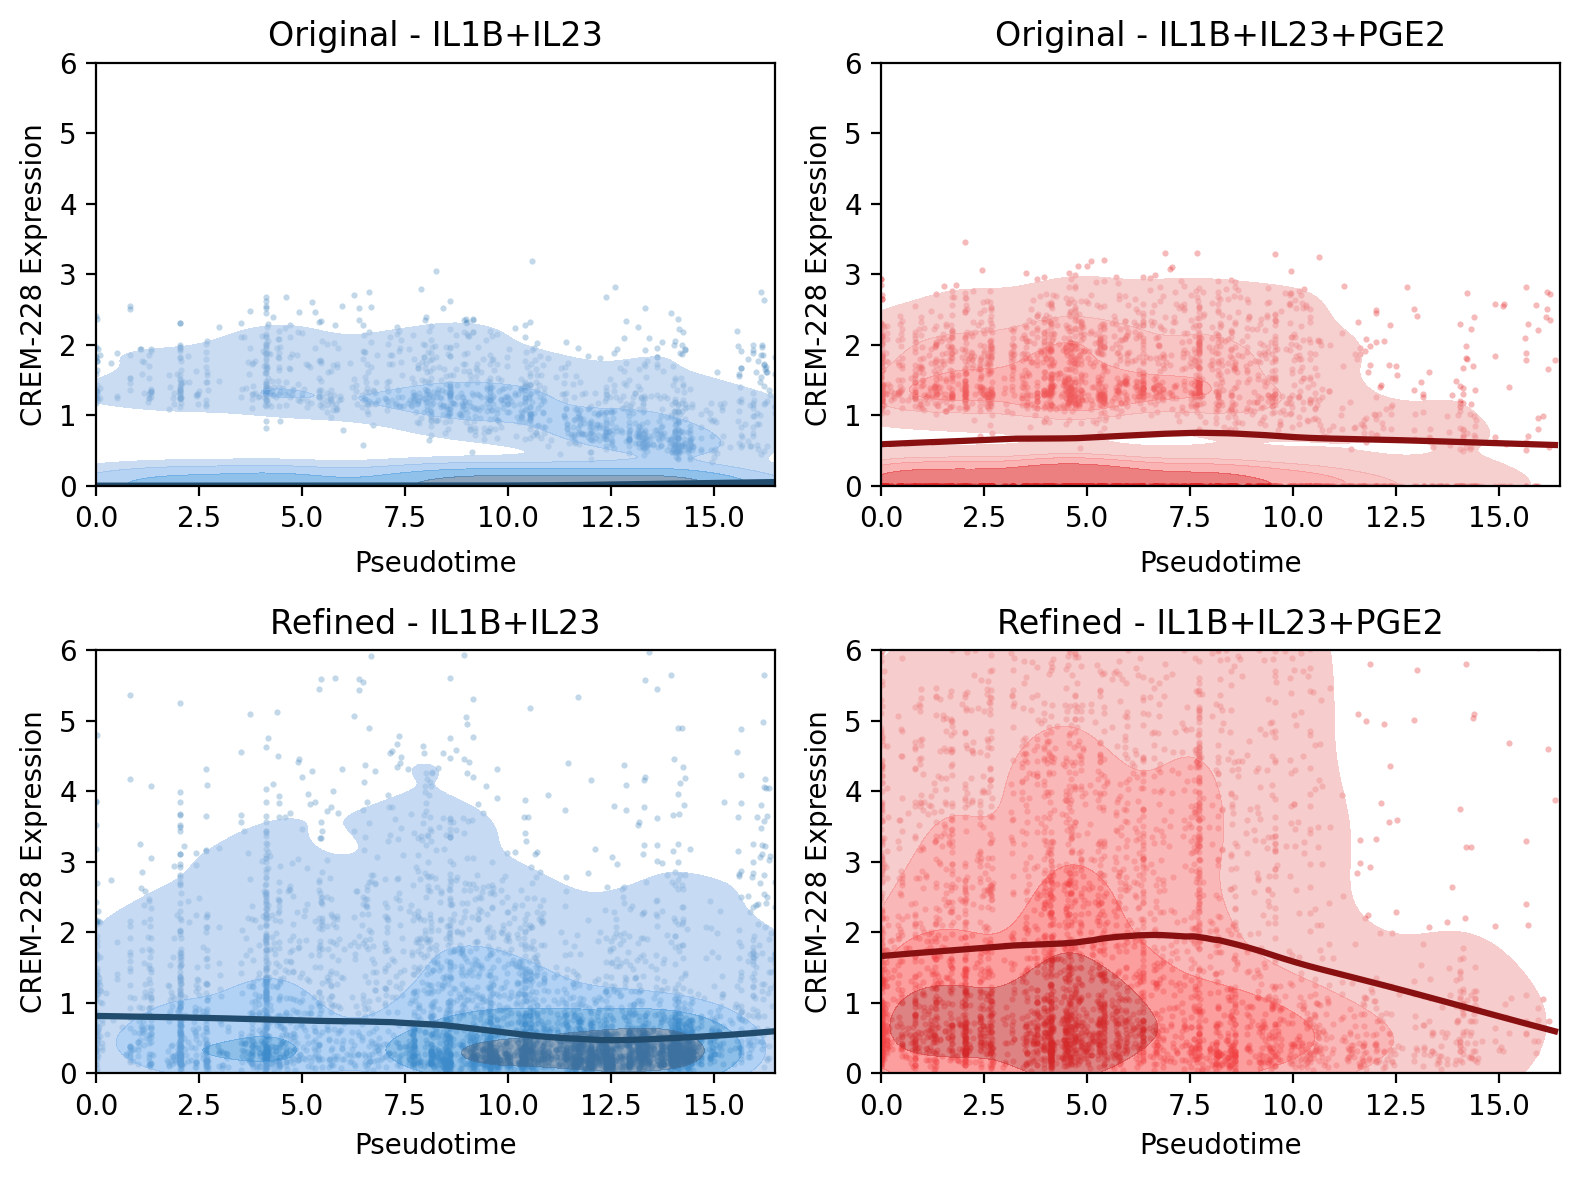

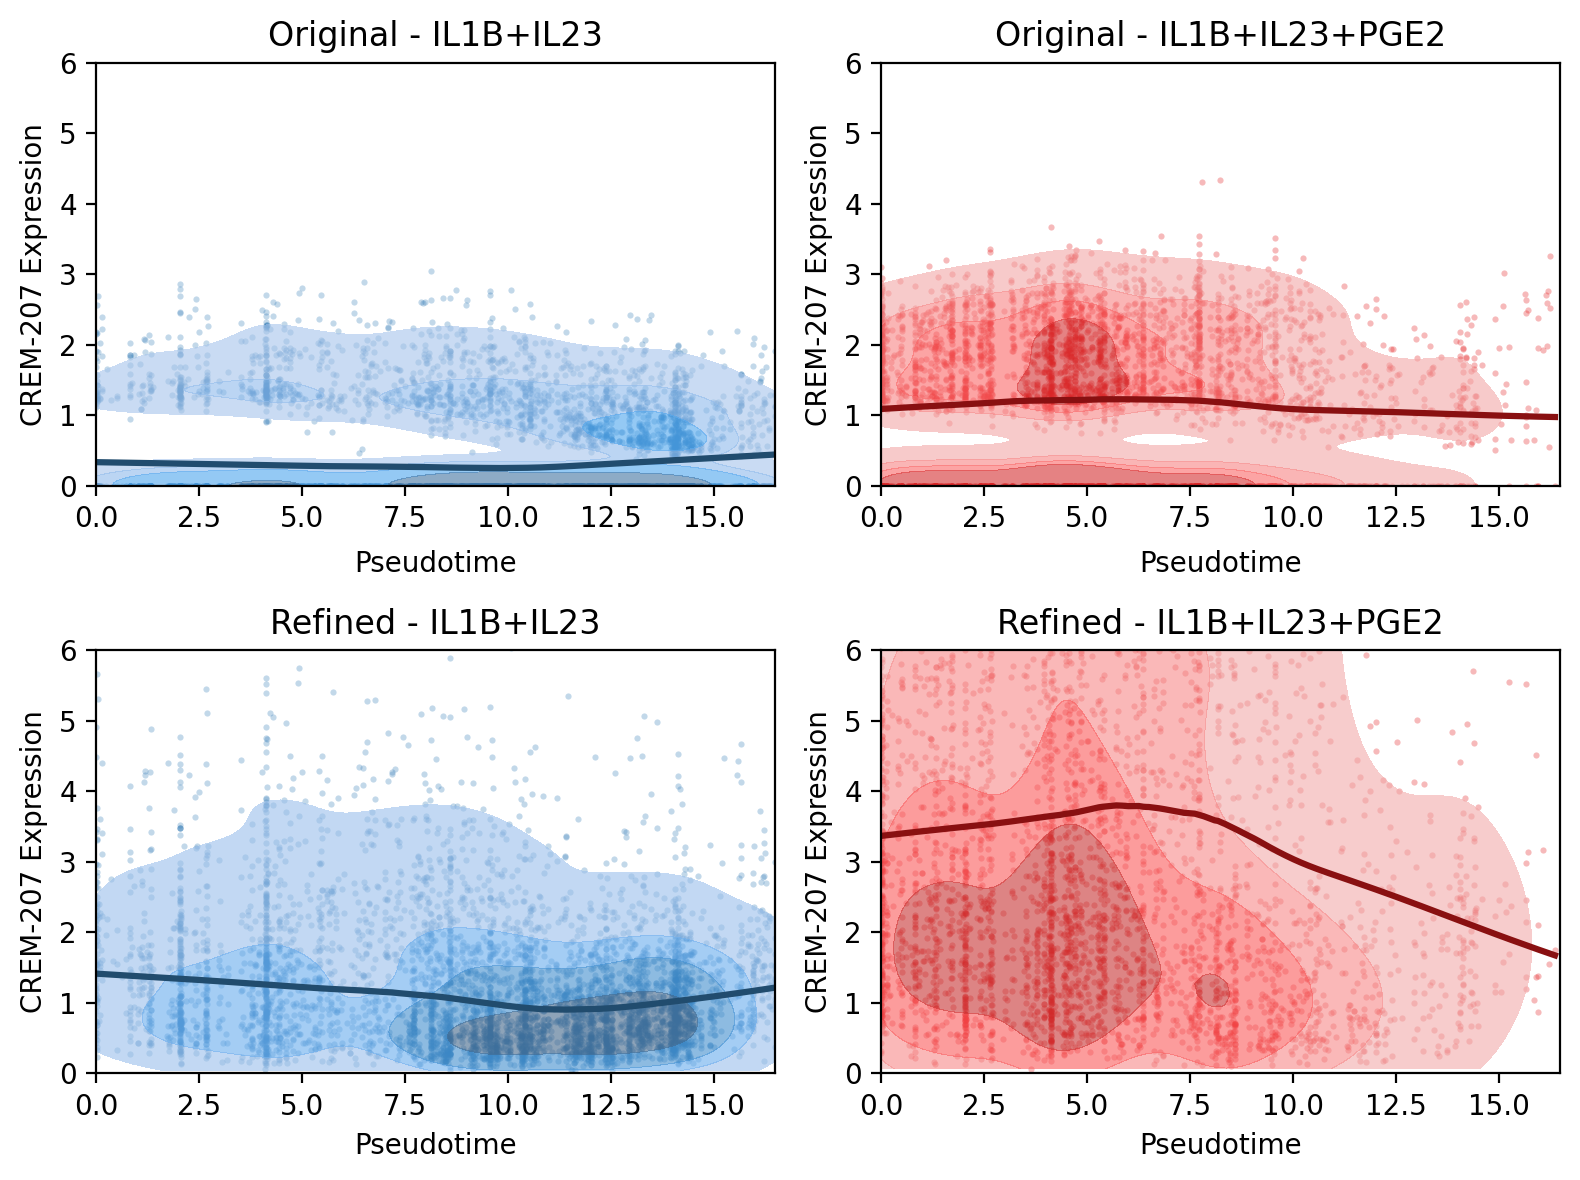

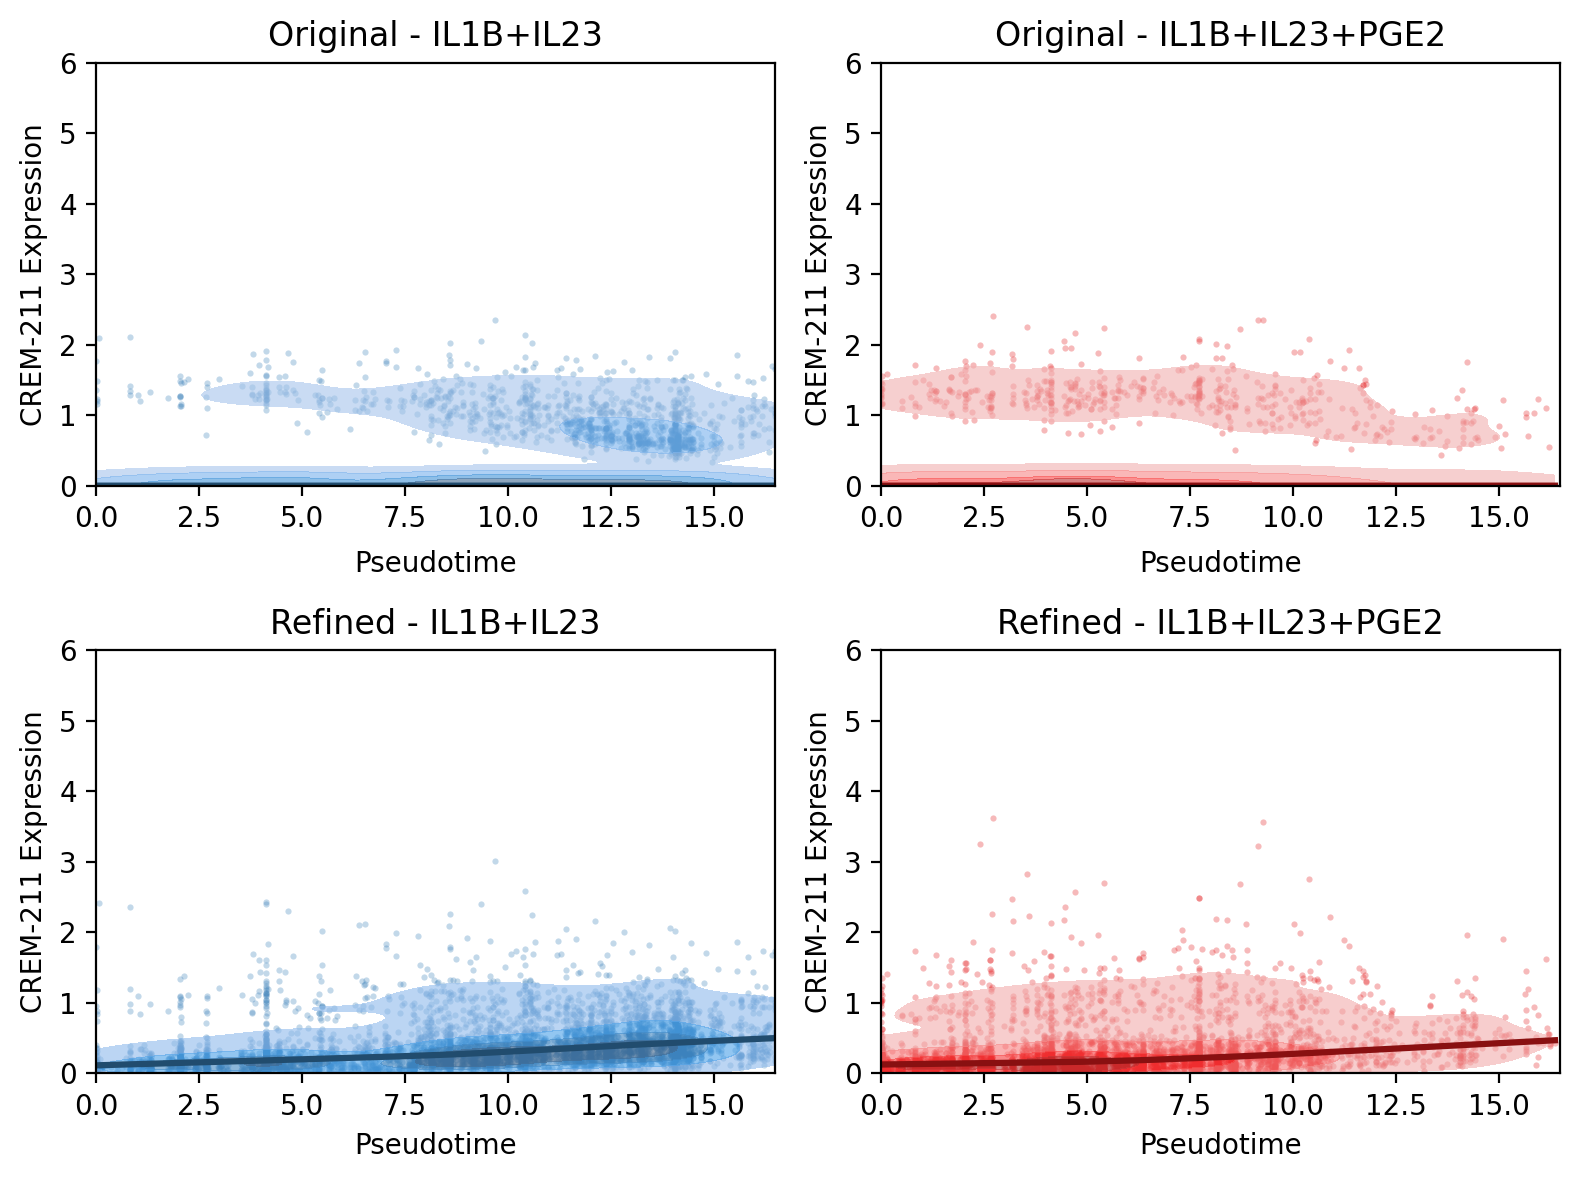

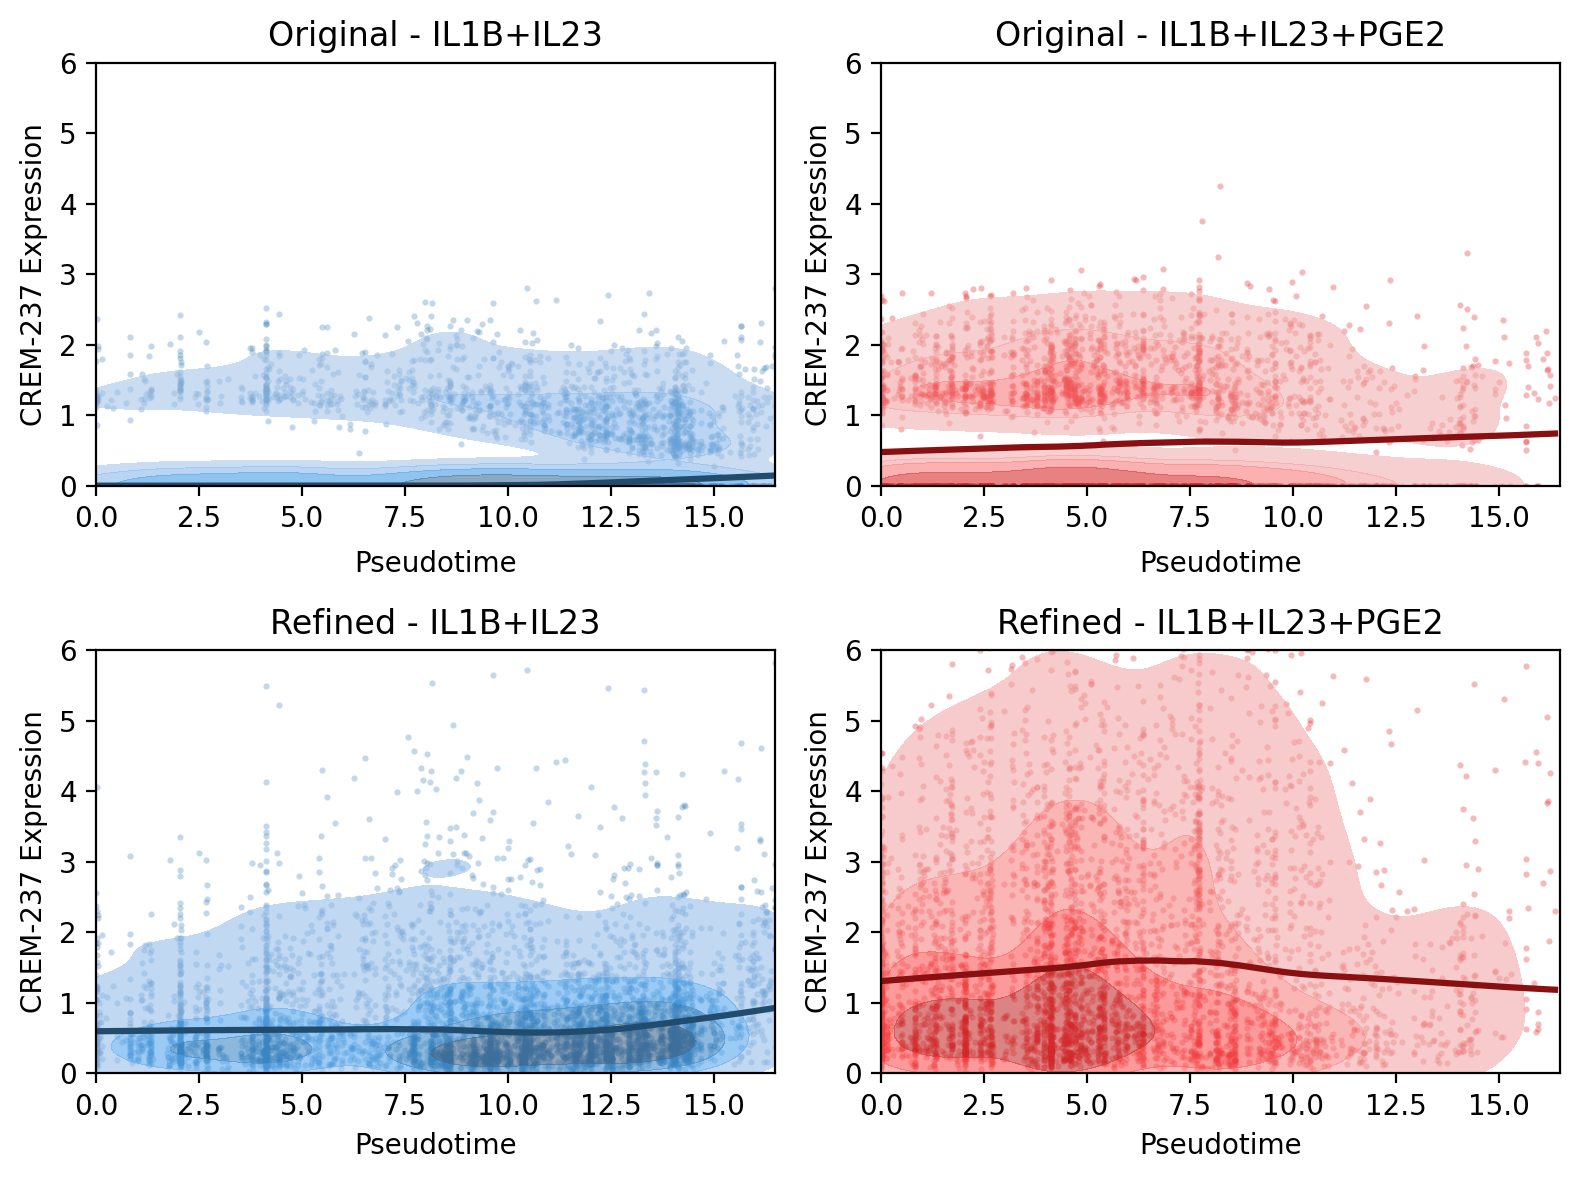

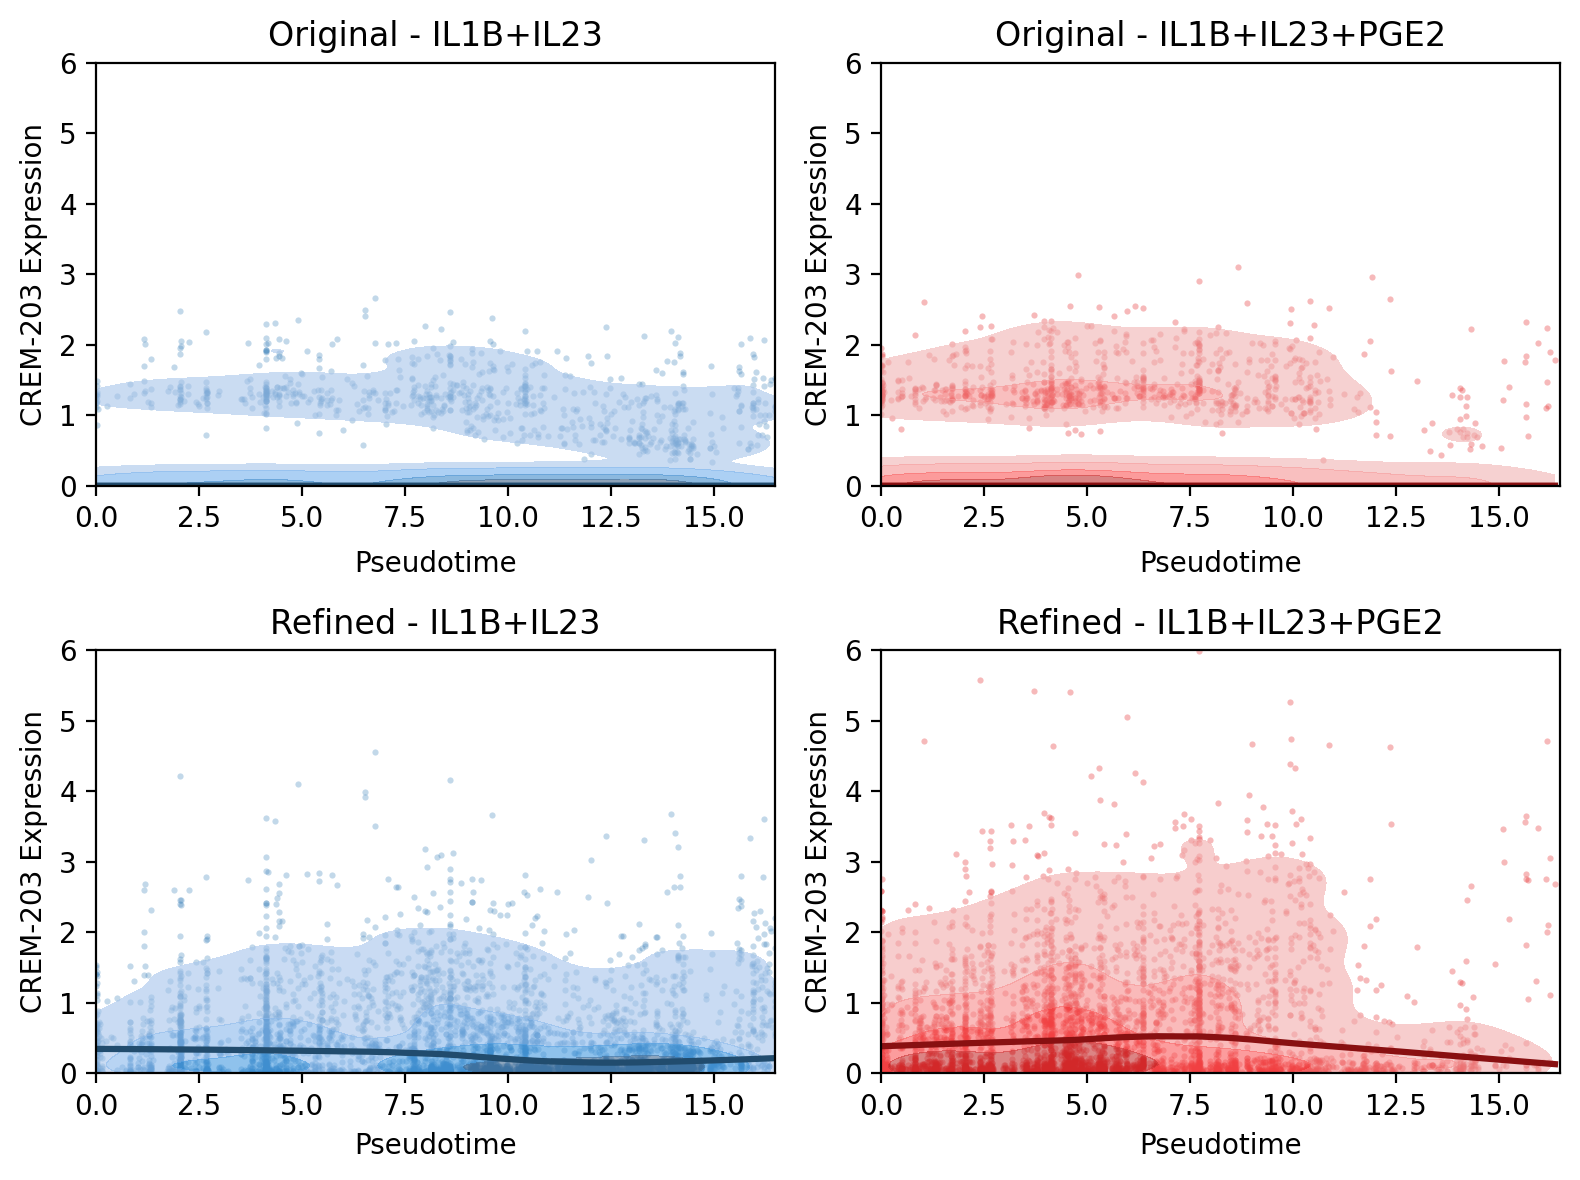

In [8]:
adata_raw, adata_refined, pseudotime_metadata = read_data('8fc', '20230426')

adata_w_refined = adata_refined[adata_refined.obs["condition_time"].str.endswith("PGE2")].copy()

adata_wo_refined = adata_refined[~adata_refined.obs["condition_time"].str.endswith("PGE2")].copy()

adata_w_raw = adata_raw[adata_raw.obs["condition_time"].str.endswith("PGE2")].copy()

adata_wo_raw = adata_raw[~adata_raw.obs["condition_time"].str.endswith("PGE2")].copy()

adata_dict = {
    'with_pge2': (adata_w_raw,  adata_w_refined),
    'no_pge2':   (adata_wo_raw, adata_wo_refined),
}

isoform_names = ['CREM-228','CREM-207', 'CREM-211','CREM-237', 'CREM-203']

for iso in isoform_names:
    plot_isoform_2x2(adata_dict, iso, ylim=(0,6))

4fc

/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/tmp/ipython-input-762459732.py:19: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_refined.obs['pseudotime'] = pseudotime_metadata.set_index('cell_names')['pseudotime'].loc[adata_refined.obs.index].values


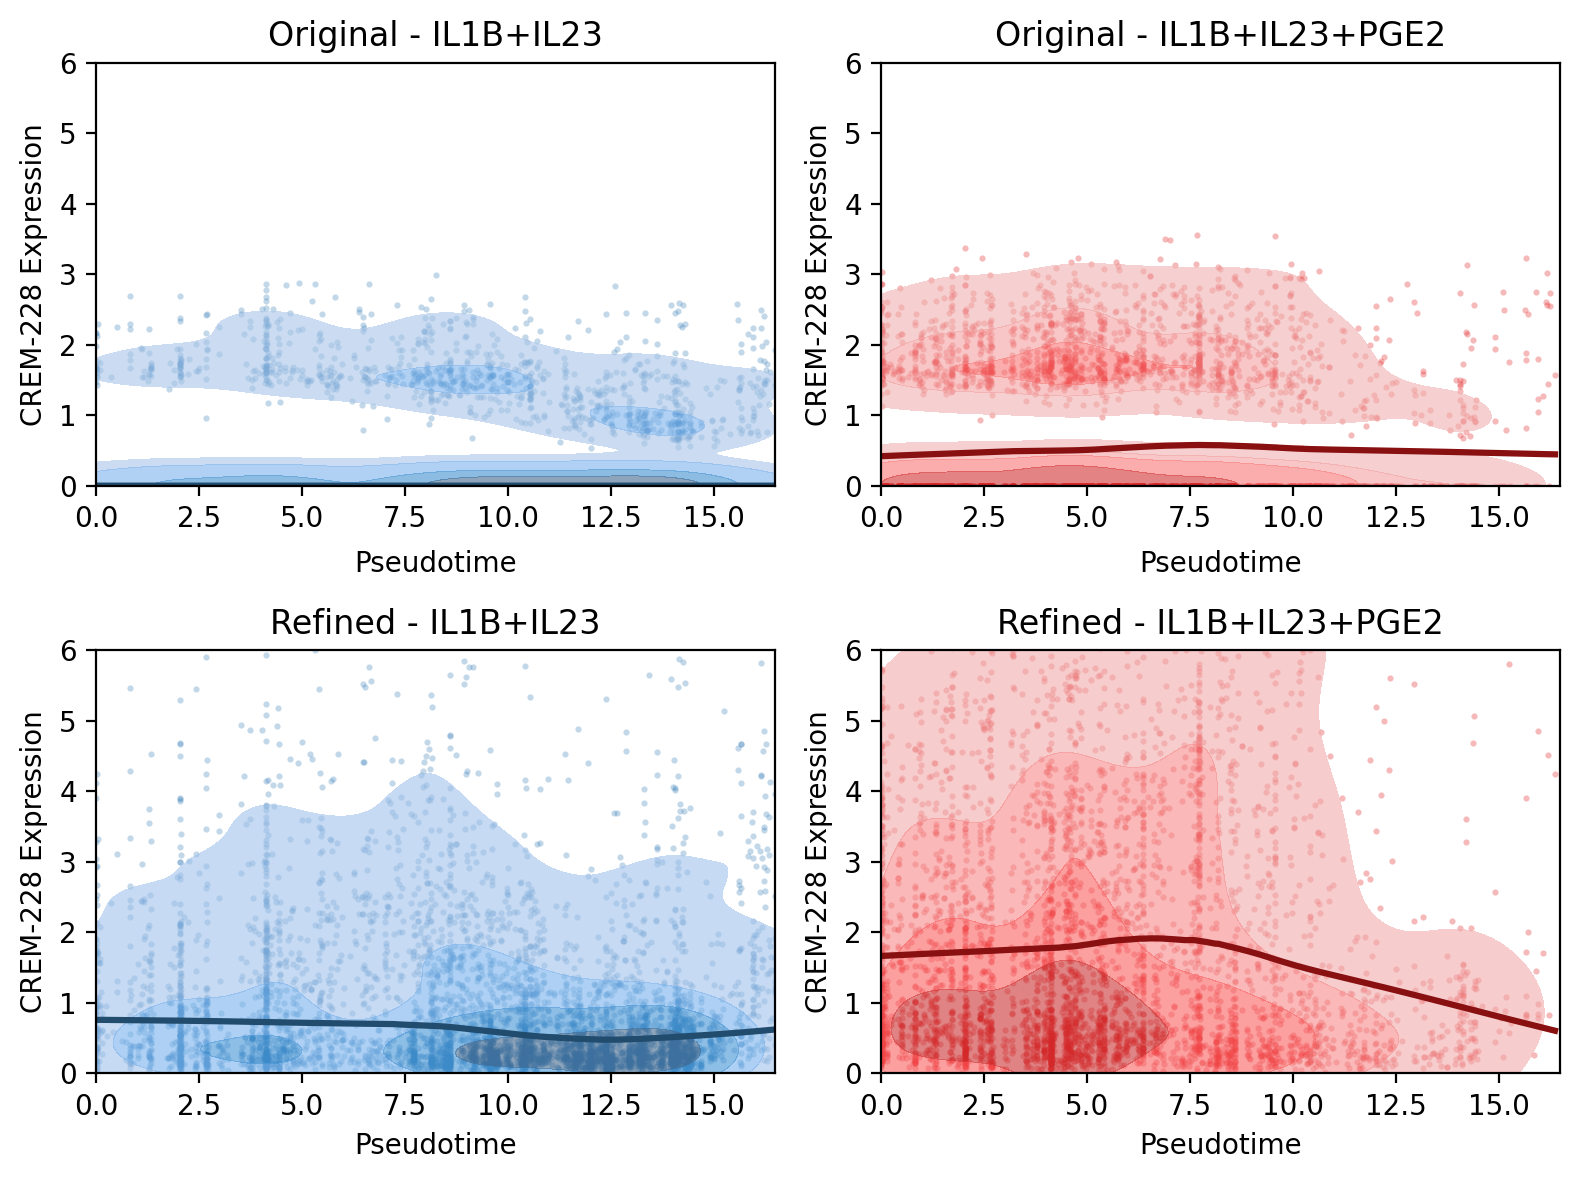

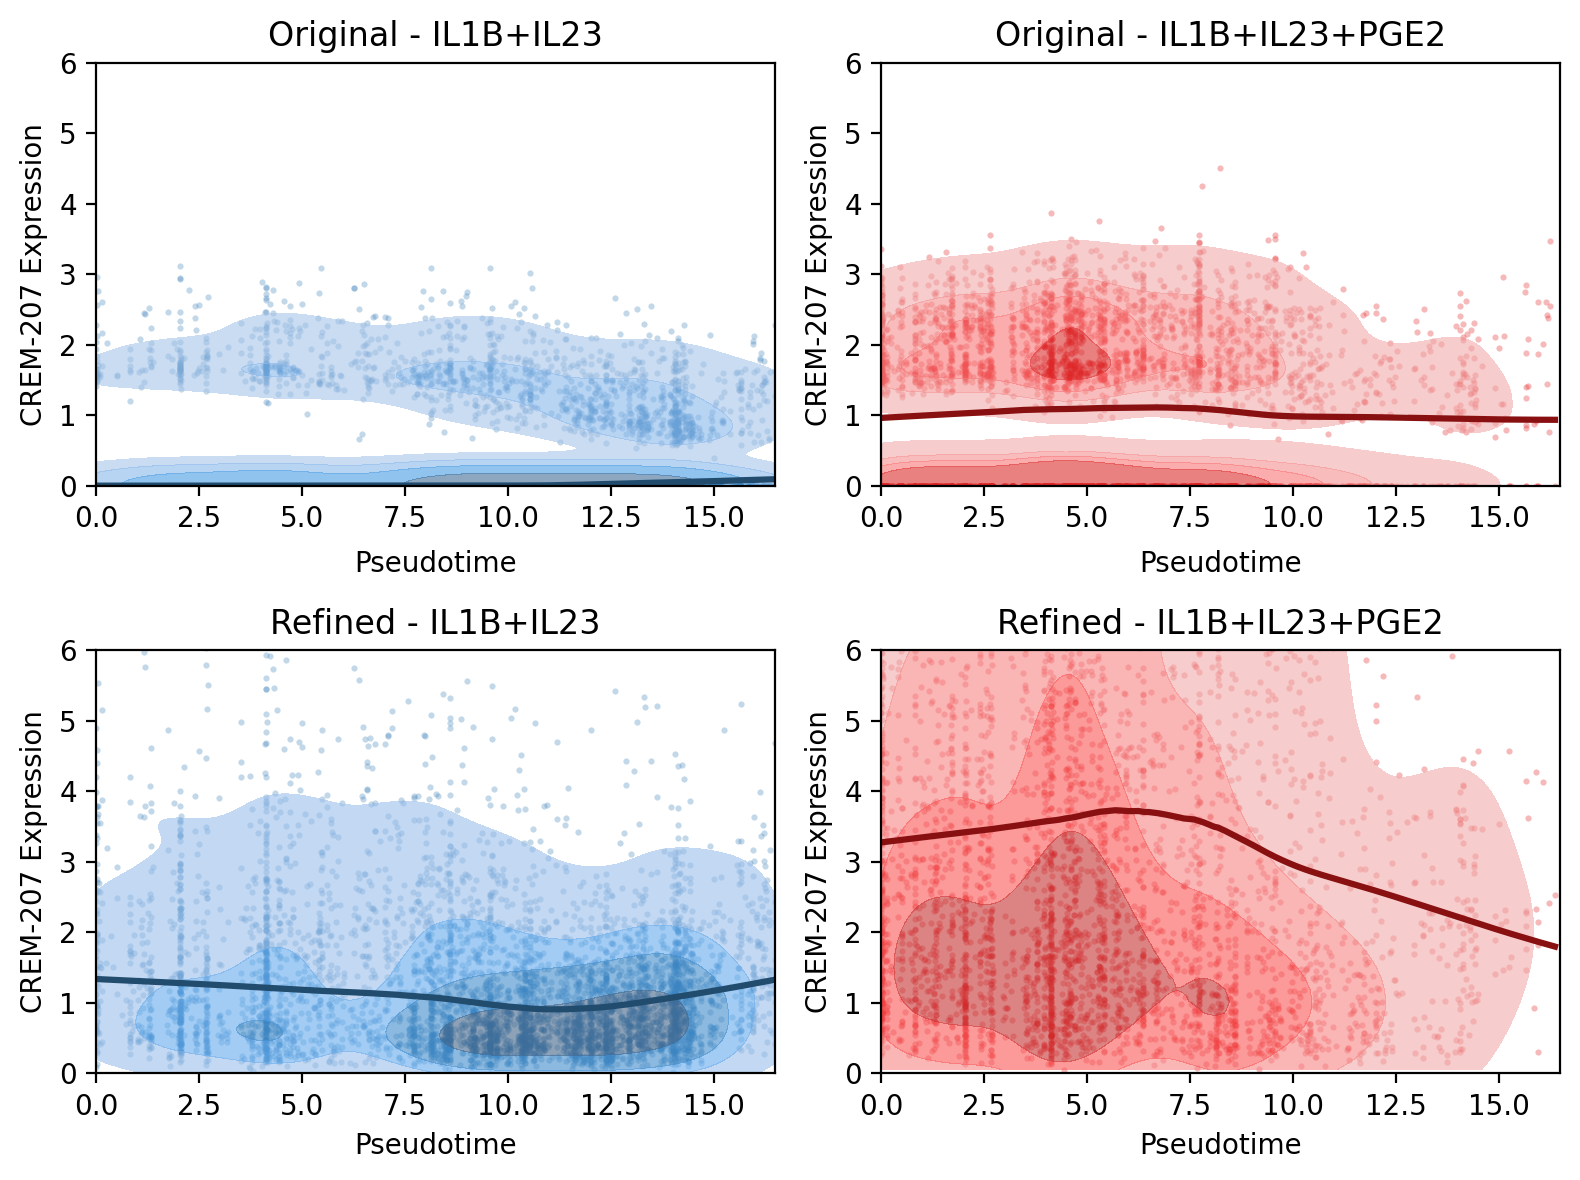

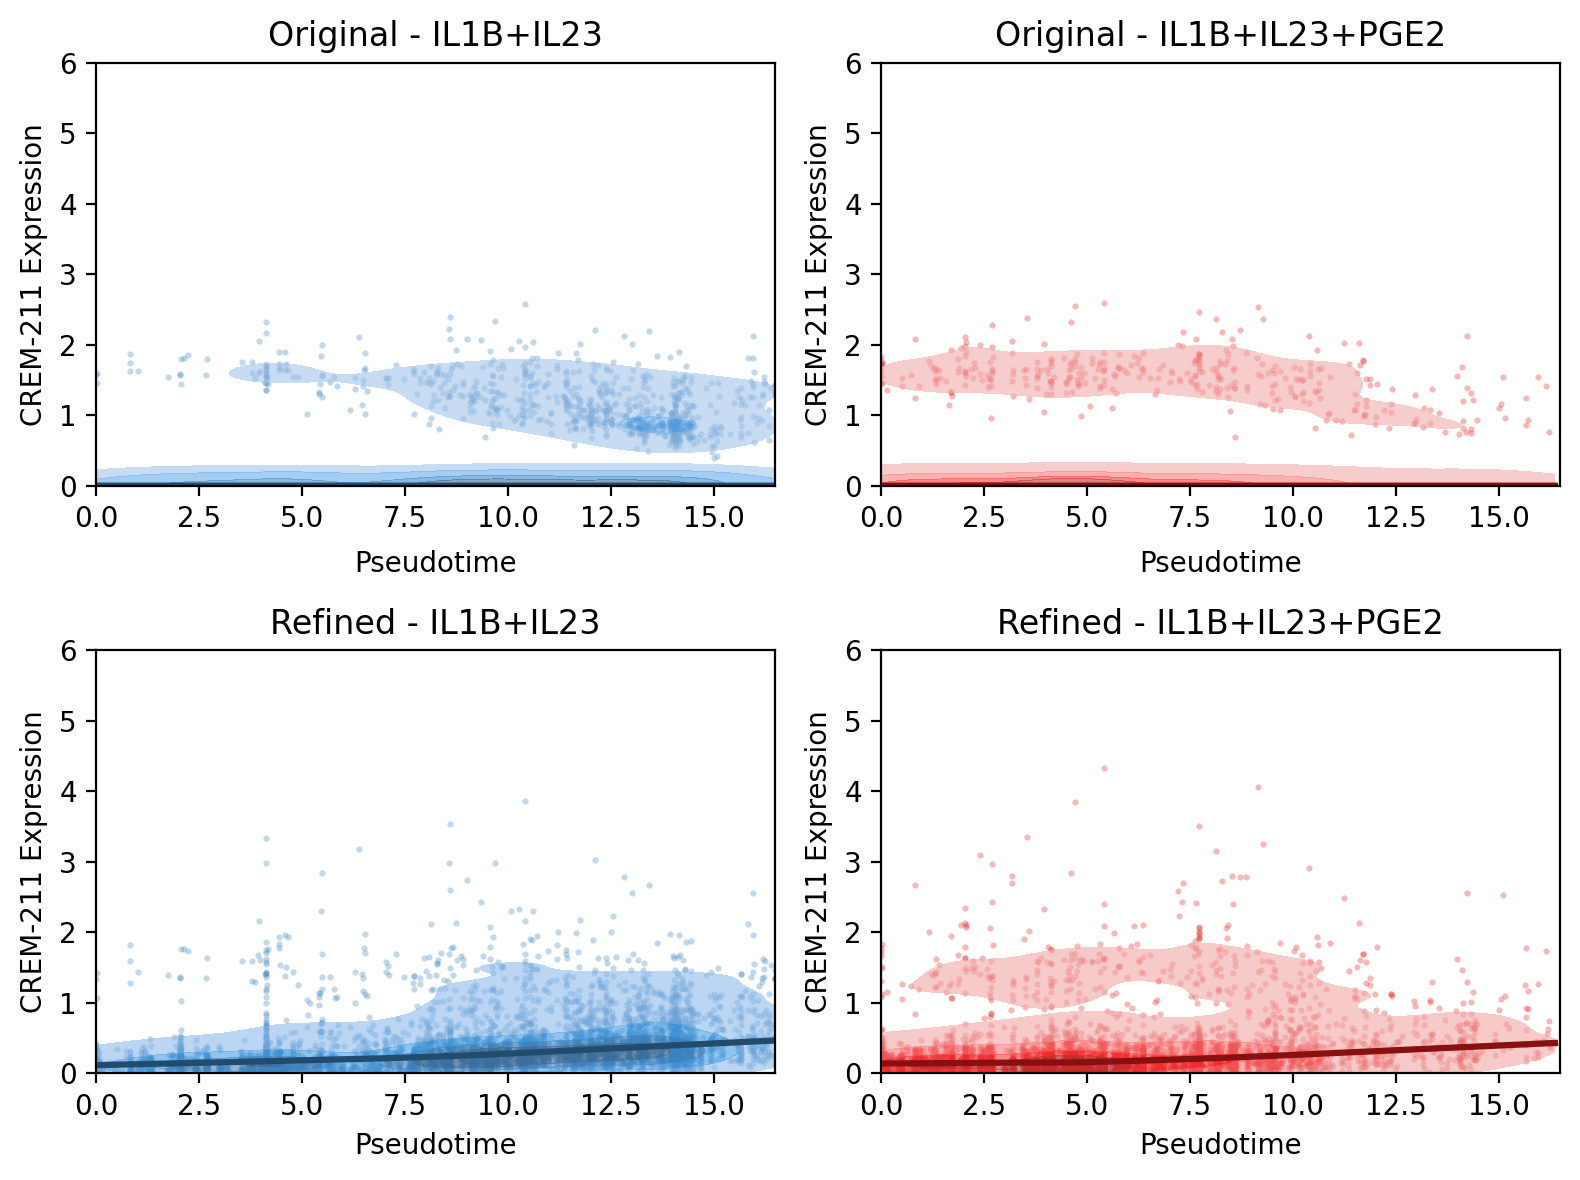

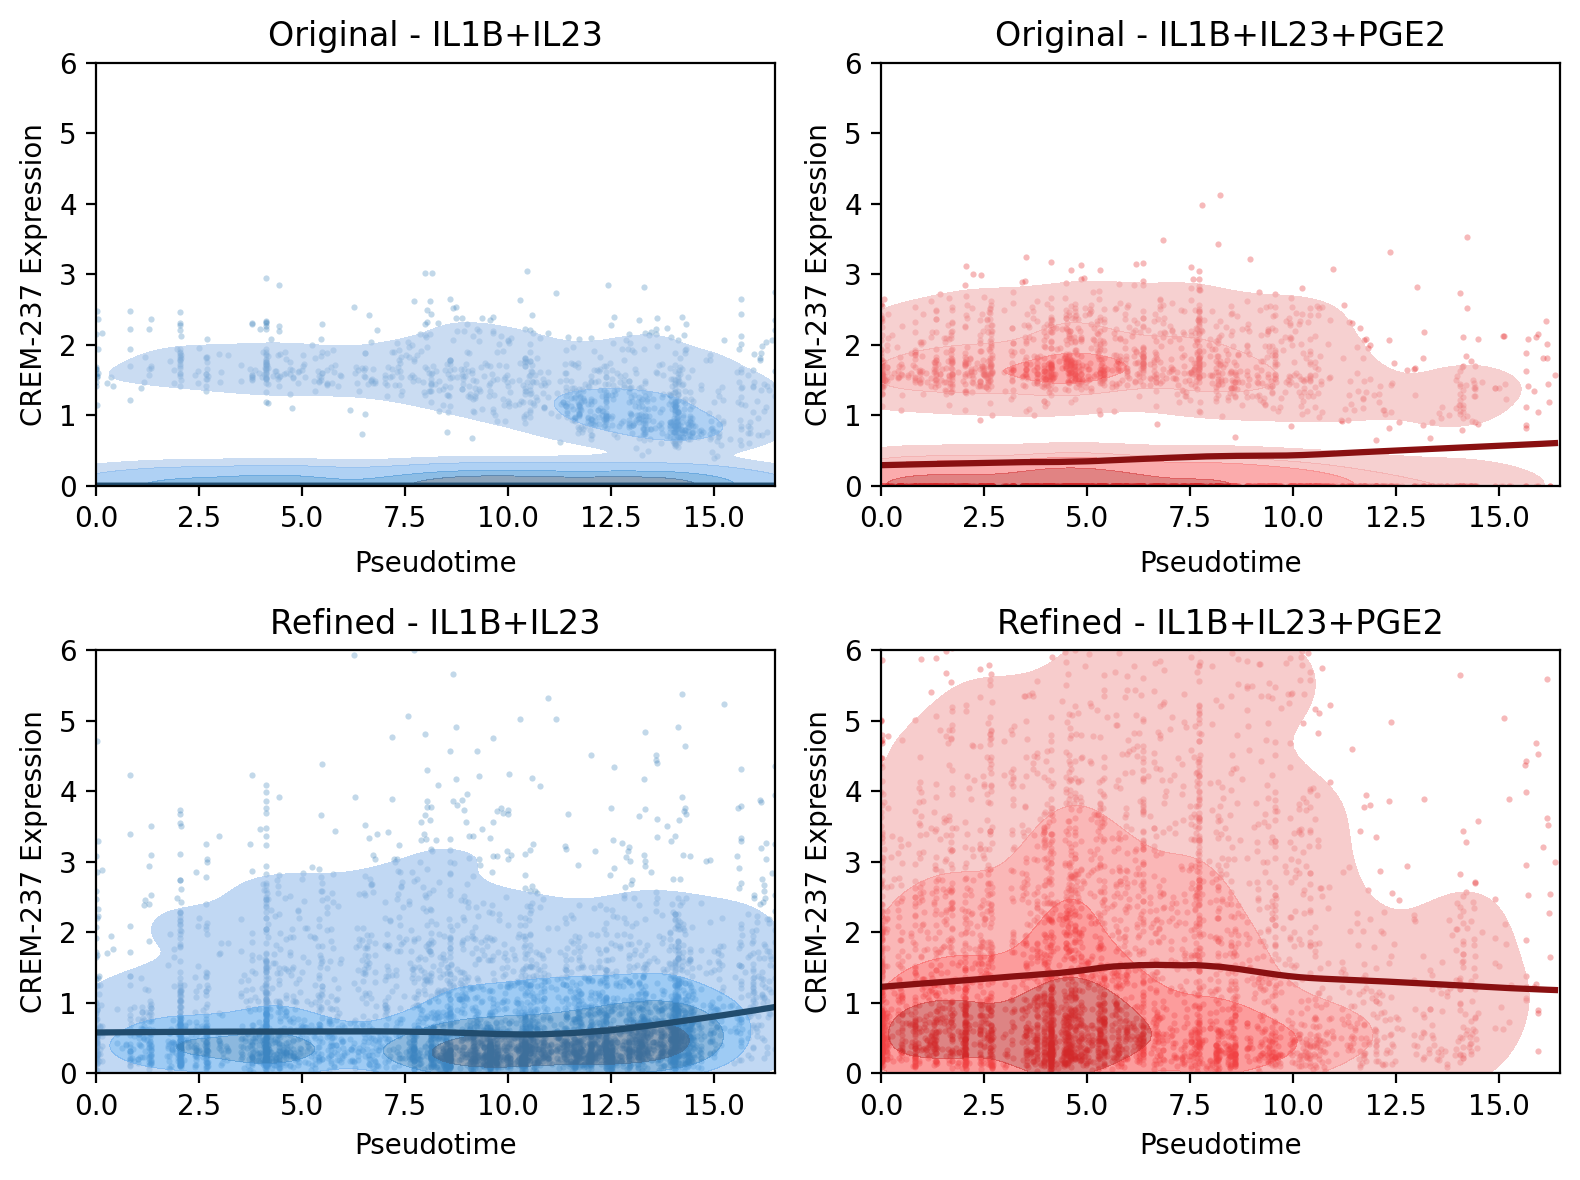

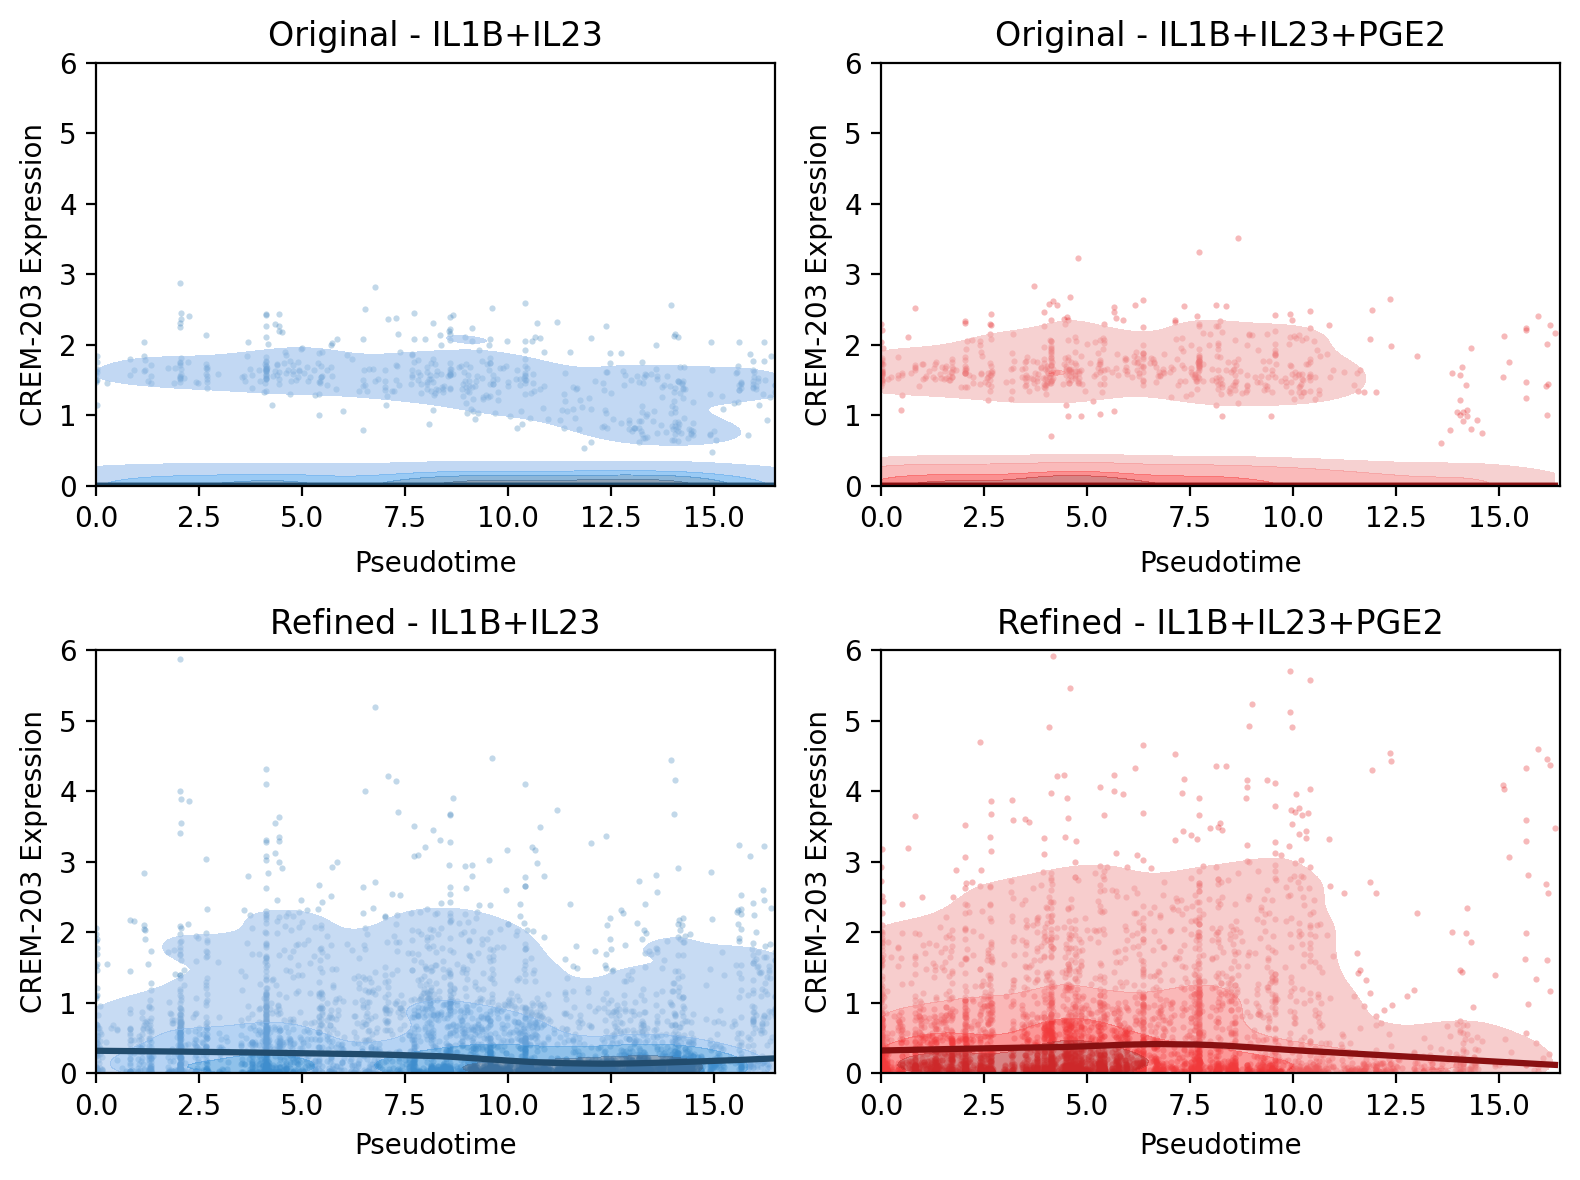

In [9]:
adata_raw, adata_refined, pseudotime_metadata = read_data('4fc', '20230426')

adata_w_refined = adata_refined[adata_refined.obs["condition_time"].str.endswith("PGE2")].copy()

adata_wo_refined = adata_refined[~adata_refined.obs["condition_time"].str.endswith("PGE2")].copy()

adata_w_raw = adata_raw[adata_raw.obs["condition_time"].str.endswith("PGE2")].copy()

adata_wo_raw = adata_raw[~adata_raw.obs["condition_time"].str.endswith("PGE2")].copy()

adata_dict = {
    'with_pge2': (adata_w_raw,  adata_w_refined),
    'no_pge2':   (adata_wo_raw, adata_wo_refined),
}

isoform_names = ['CREM-228','CREM-207', 'CREM-211','CREM-237', 'CREM-203']

for iso in isoform_names:
    plot_isoform_2x2(adata_dict, iso, ylim=(0,6))

2fc

/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/tmp/ipython-input-762459732.py:19: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_refined.obs['pseudotime'] = pseudotime_metadata.set_index('cell_names')['pseudotime'].loc[adata_refined.obs.index].values


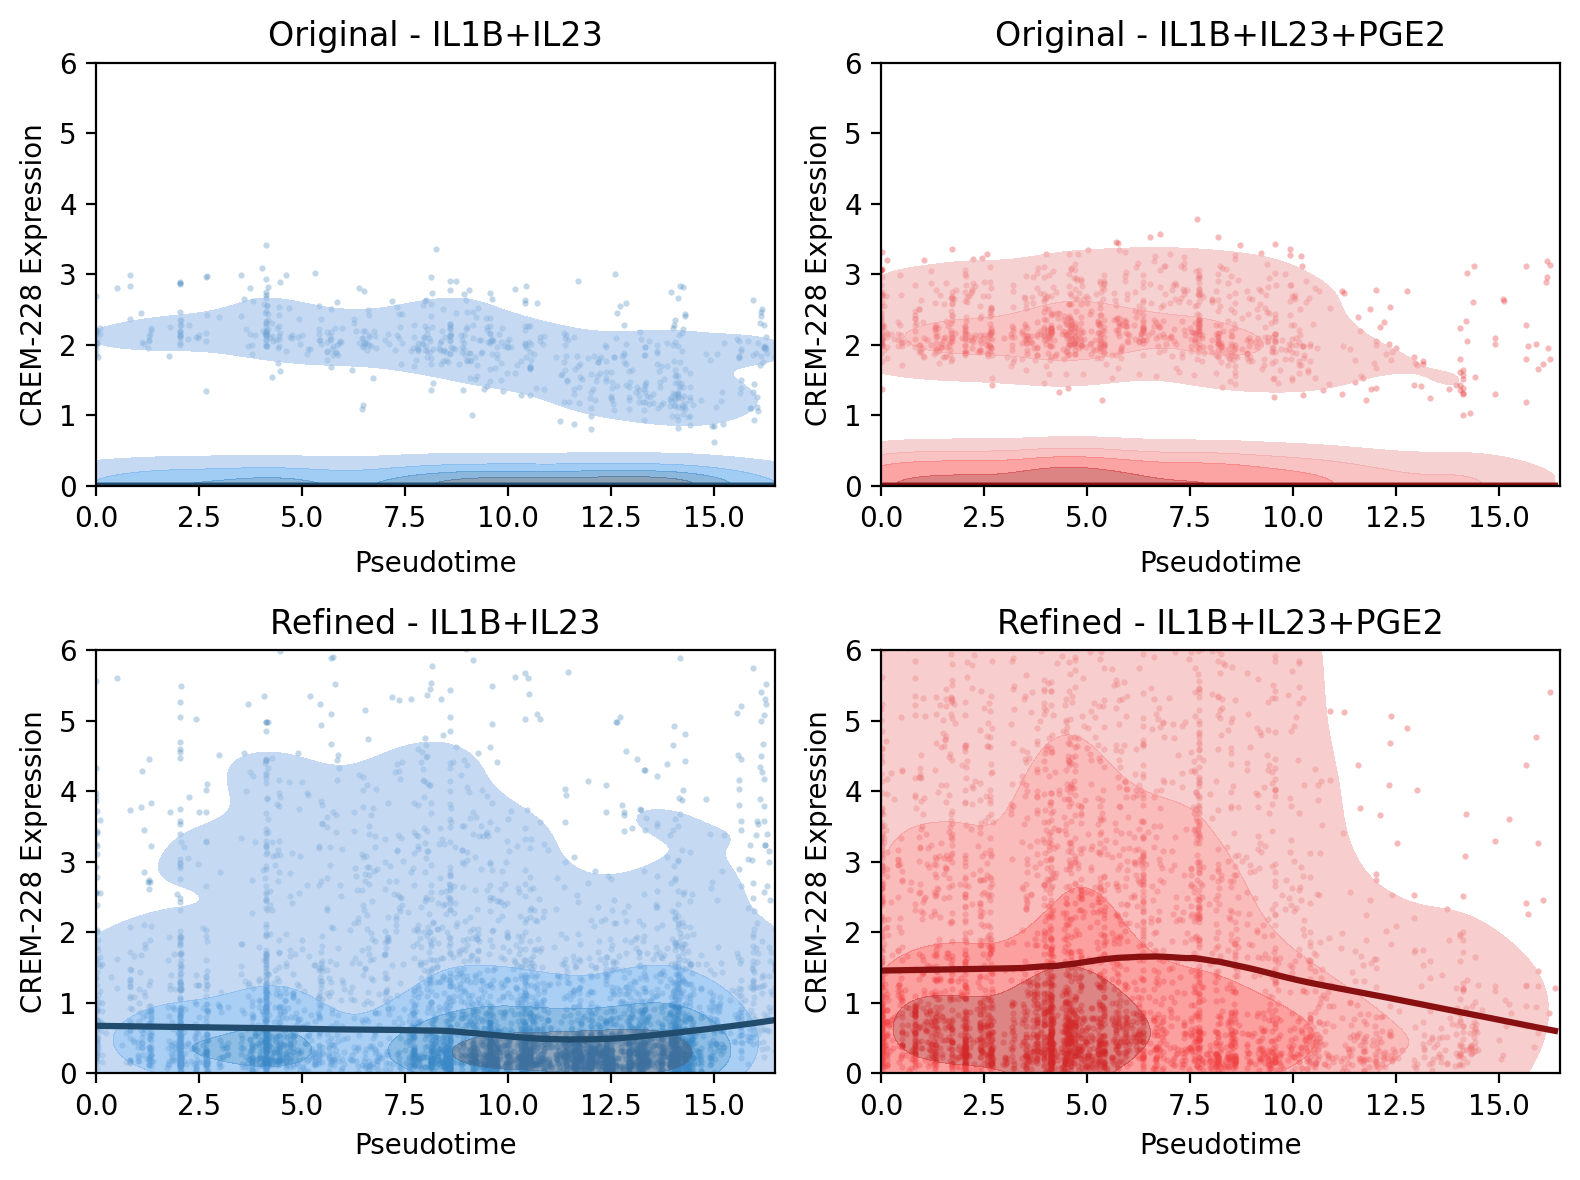

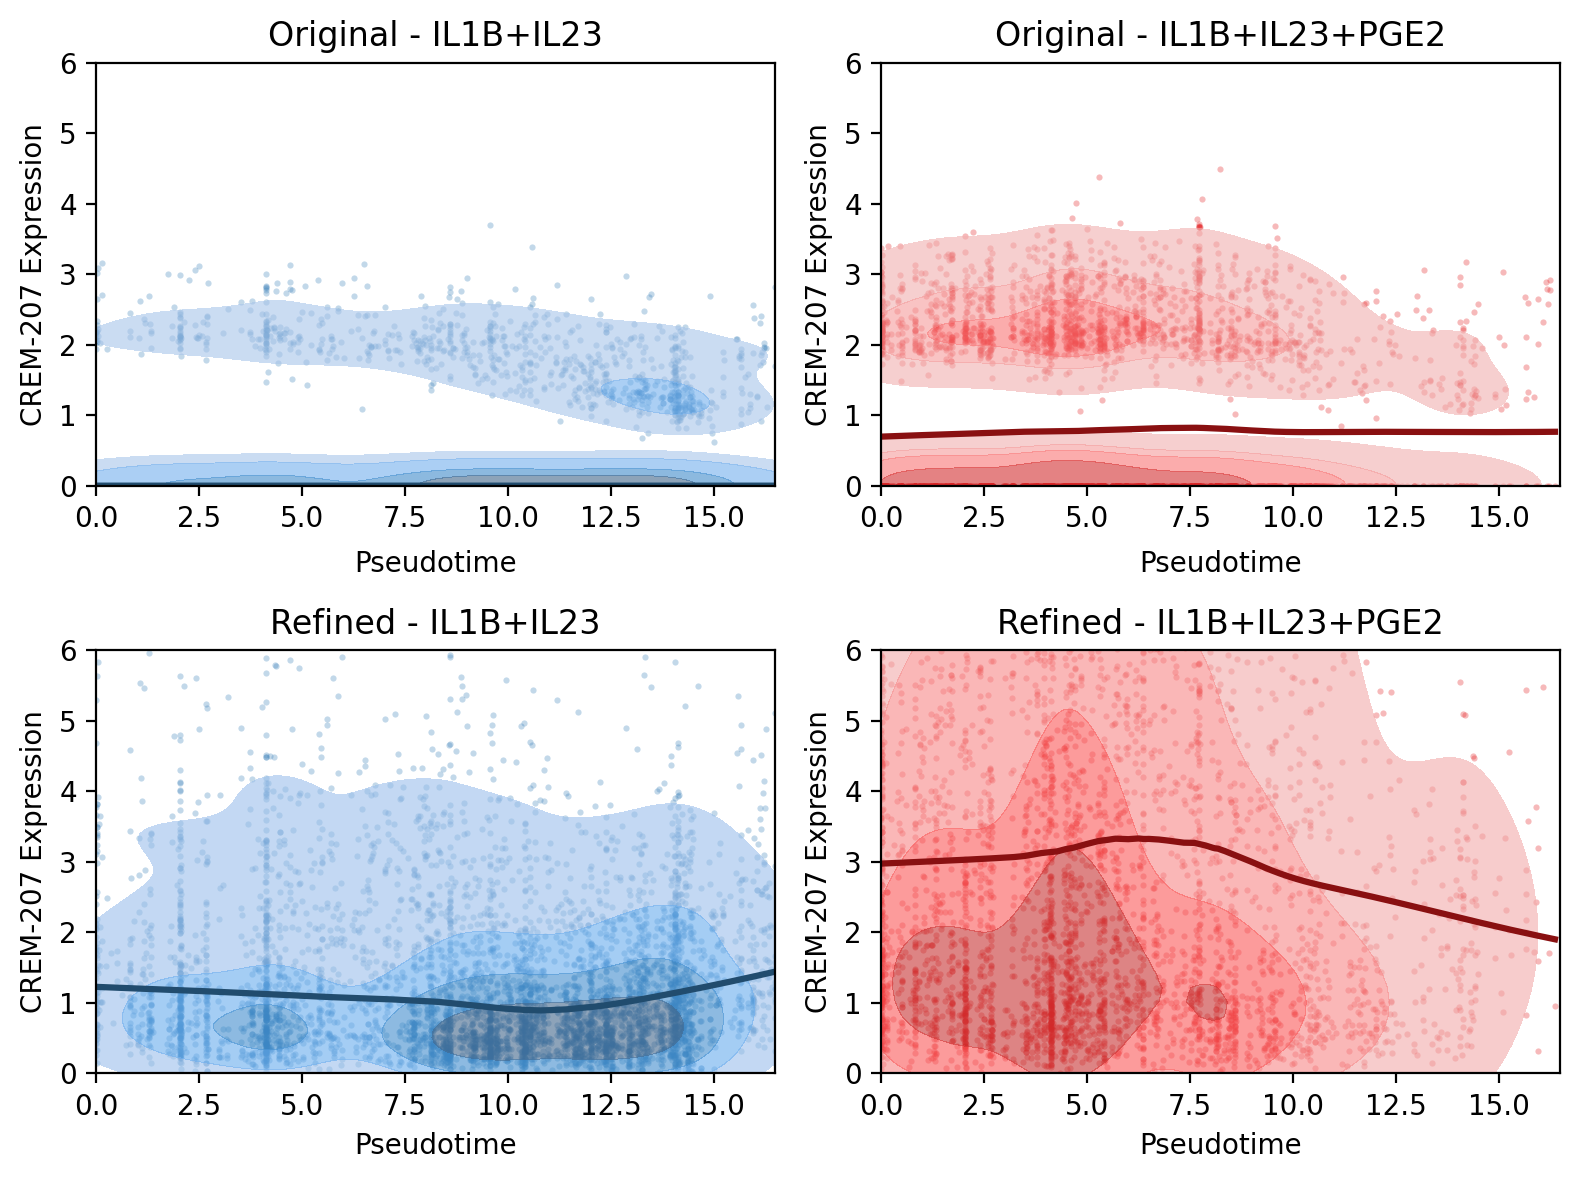

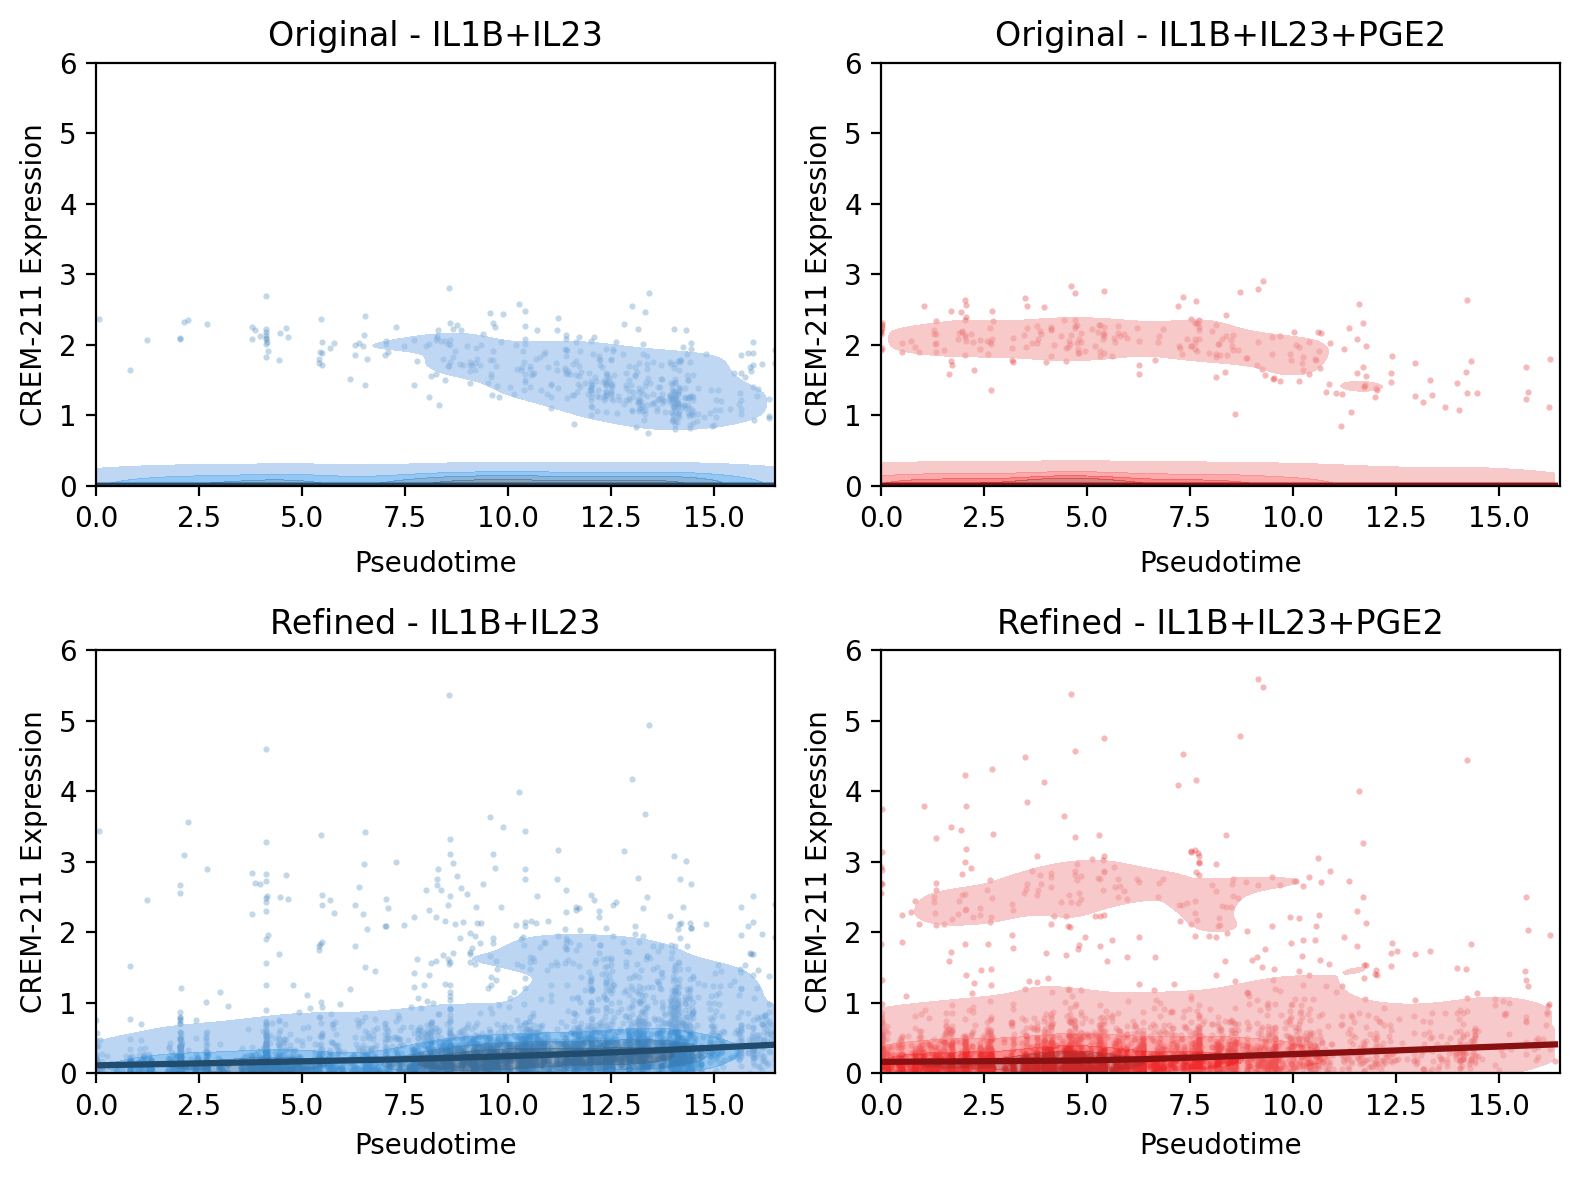

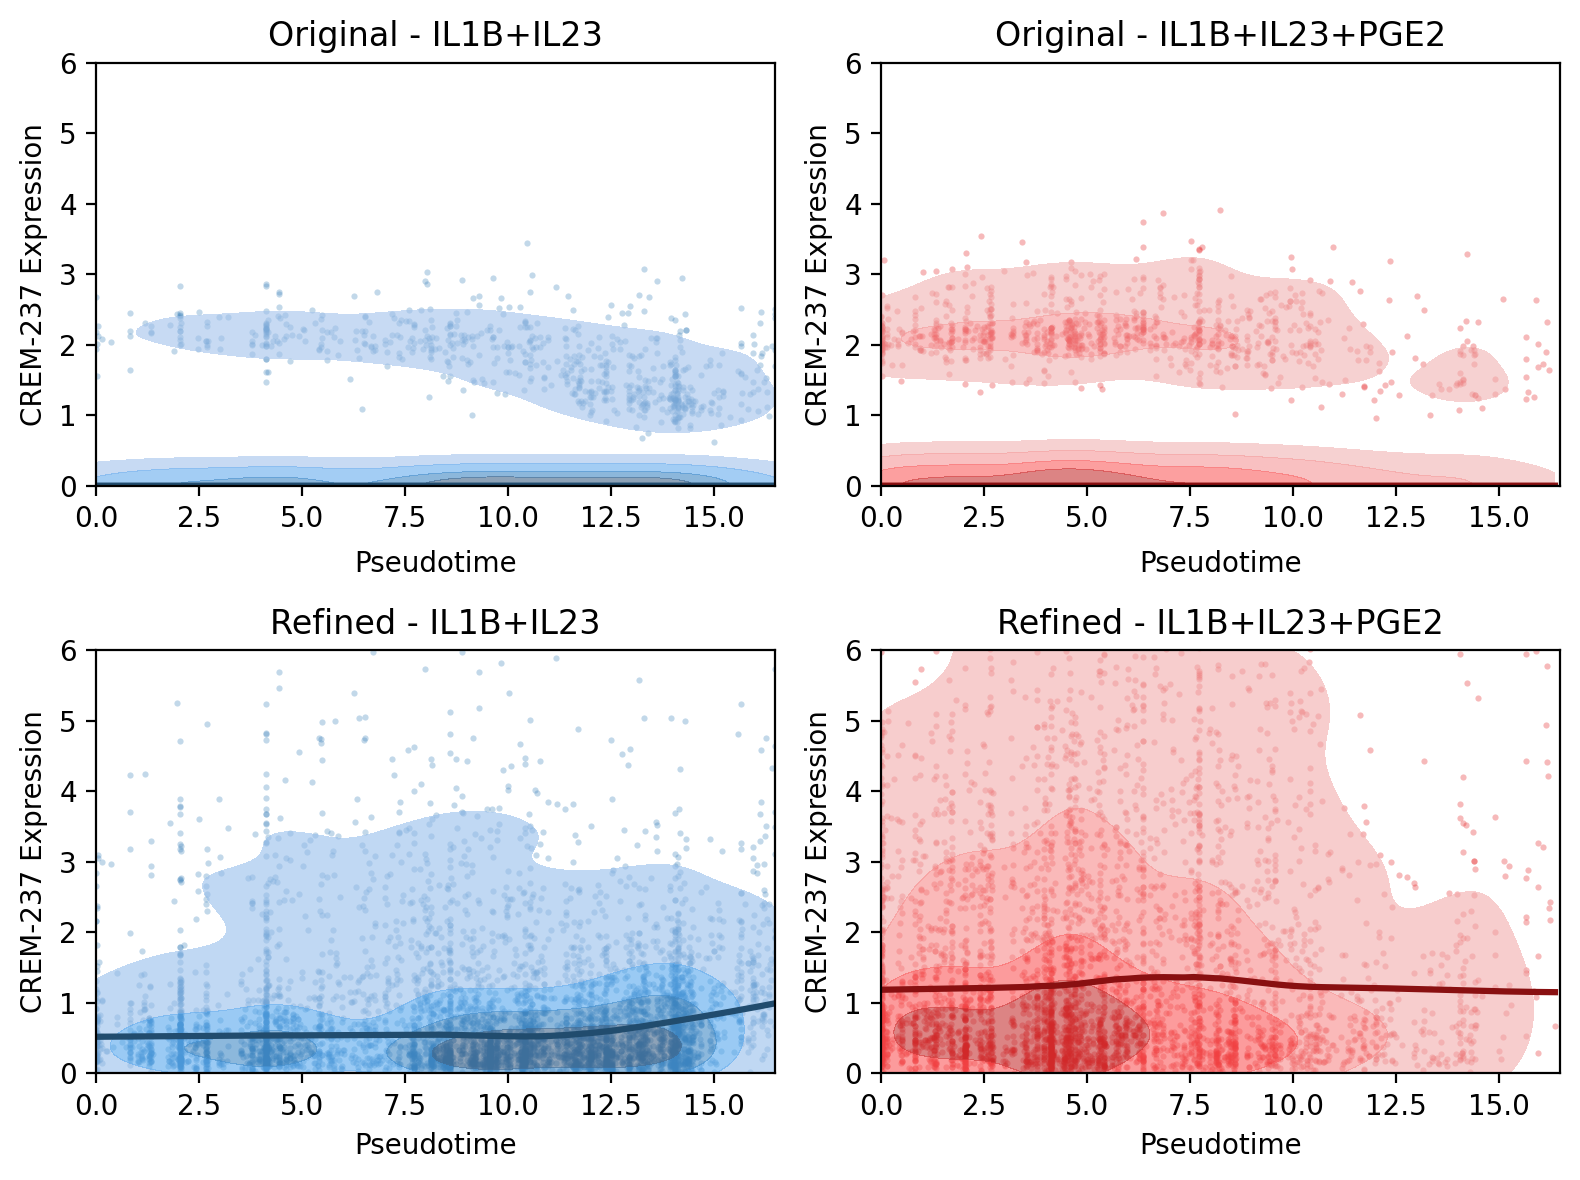

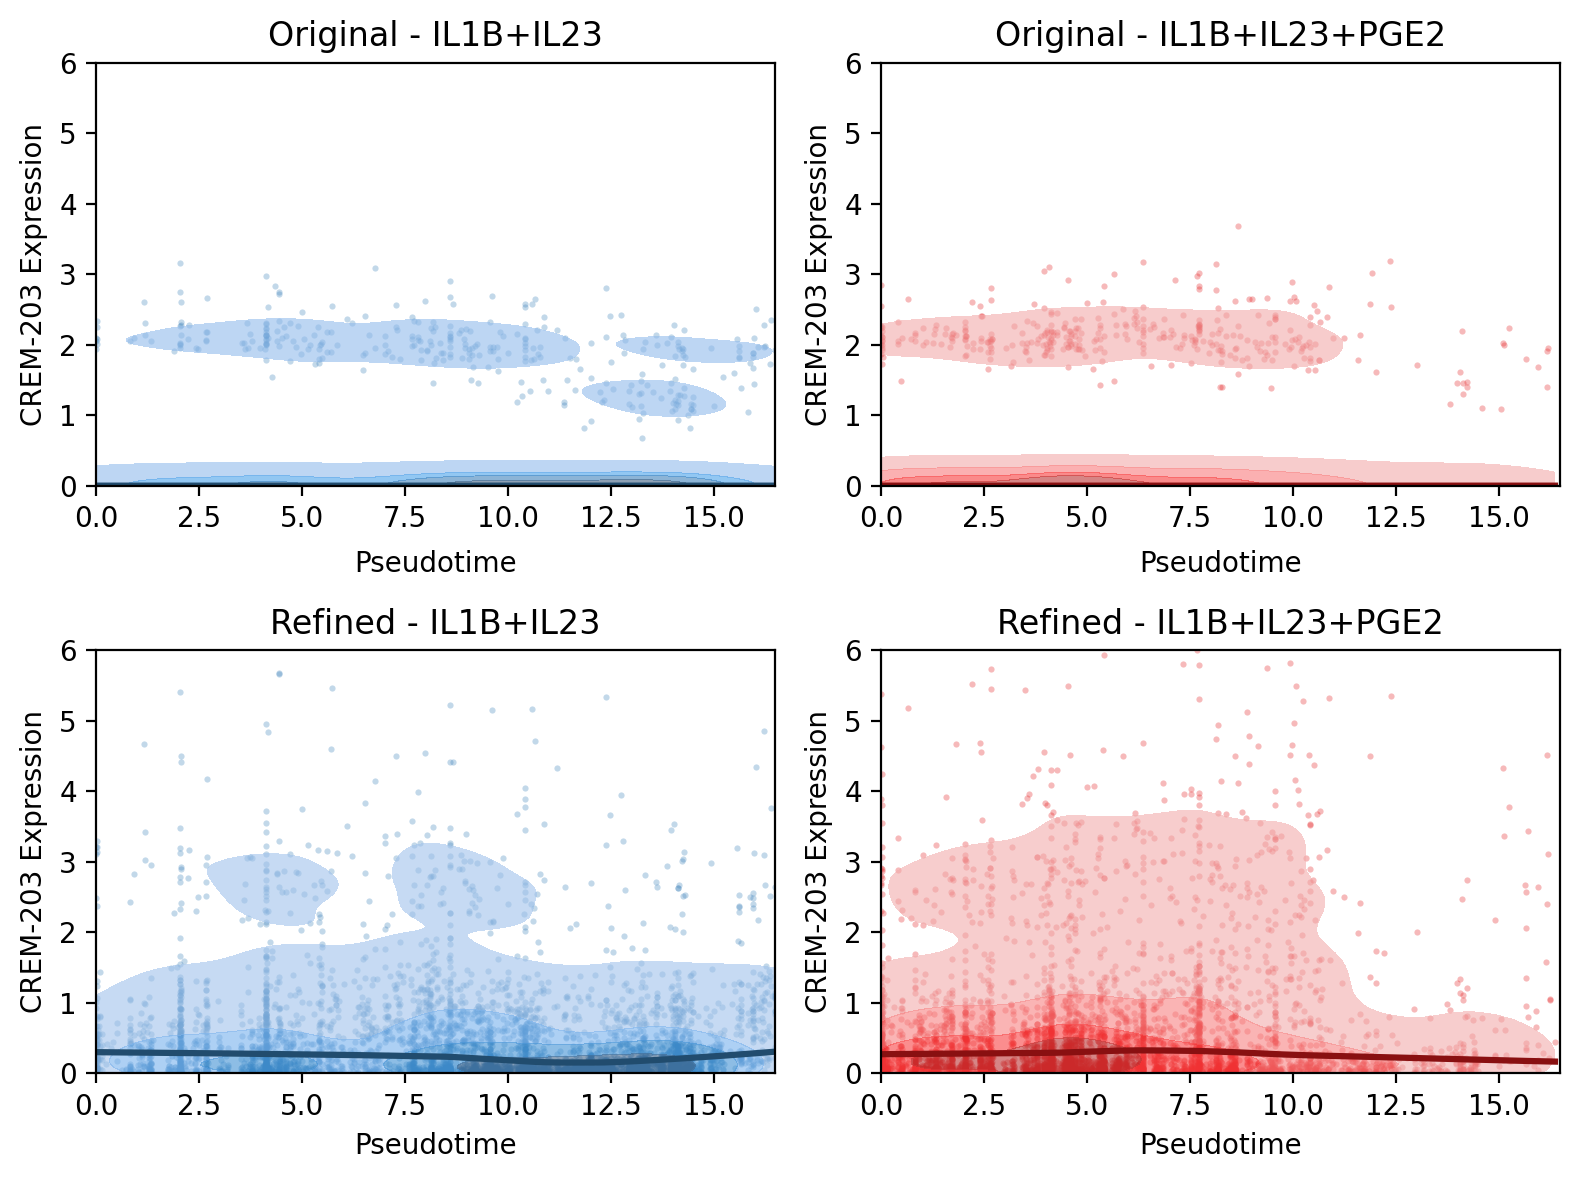

In [10]:
adata_raw, adata_refined, pseudotime_metadata = read_data('2fc', '20230426')

adata_w_refined = adata_refined[adata_refined.obs["condition_time"].str.endswith("PGE2")].copy()

adata_wo_refined = adata_refined[~adata_refined.obs["condition_time"].str.endswith("PGE2")].copy()

adata_w_raw = adata_raw[adata_raw.obs["condition_time"].str.endswith("PGE2")].copy()

adata_wo_raw = adata_raw[~adata_raw.obs["condition_time"].str.endswith("PGE2")].copy()

adata_dict = {
    'with_pge2': (adata_w_raw,  adata_w_refined),
    'no_pge2':   (adata_wo_raw, adata_wo_refined),
}

isoform_names = ['CREM-228','CREM-207', 'CREM-211','CREM-237', 'CREM-203']

for iso in isoform_names:
    plot_isoform_2x2(adata_dict, iso, ylim=(0,6))